# Combine clouds

Combine clouds from different files and interpolate missing values.

## Prepare the notebook

In [66]:
from glob import glob
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from calendar import monthrange
from datetime import date

## Load human evaluations

In [107]:
clouds = pd.read_hdf('clouds_ctio_blanco.h5').set_index(['date', 'quarter'])
clouds.head()

sday  eday  month  year  clouds source
date       quarter                                        
1975-01-01 1           1     2      1  1975       0   ctio
           2           1     2      1  1975       0   ctio
           3           1     2      1  1975       0   ctio
           4           1     2      1  1975       0   ctio
1975-01-02 1           2     3      1  1975       0   ctio

### Distributions by month

In [3]:
monthly_cloud_counts = clouds.query('clouds < 9').groupby(['month', 'clouds']).sday.count().rename('quarters').to_frame().reset_index().pivot(index=['month'], columns=['clouds'])
monthly_cloud_counts

quarters                                         
clouds        0    1    2    3    4    5    6    7     8
month                                                   
1          4446  422  253  188  145   92   45   31    68
2          4156  377  178  112   86   67   51   35    52
3          4415  402  252  167  151   75   94   59   173
4          3376  501  352  215  188  137  138  176   489
5          2227  572  448  310  289  236  240  277  1024
6          2088  551  399  374  261  227  256  242   998
7          2416  436  371  285  275  160  260  175  1177
8          2821  500  372  273  220  175  198  183   996
9          2694  520  382  298  222  164  185  201   707
10         3047  658  424  276  240  171  188  139   485
11         3945  458  253  189  139  120  107  108   270
12         4236  435  227  134  110   78   76   48   122

### Build a stochastic matrix

In [4]:
transitions = pd.DataFrame({'month': clouds.month[:-1].values, 'clouds': clouds.clouds[:-1].values, 'next_clouds': clouds.clouds[1:].values, 'count': 1})
transition_counts = transitions.groupby(['month', 'clouds', 'next_clouds']).count()

Remove transitions to and from missing data:

In [5]:
transition_counts = transition_counts.reset_index().query('(clouds != 9) and (next_clouds != 9)').set_index(['month', 'clouds', 'next_clouds'])

Reshape into a matrix:

In [6]:
transition_matrix = transition_counts.unstack().fillna(0)
transition_matrix.columns = transition_matrix.columns.droplevel(0)
transition_matrix

next_clouds        0      1     2     3     4     5     6     7     8
month clouds                                                         
1     0       4148.0  135.0  50.0  48.0  23.0  17.0   5.0   2.0   7.0
      1        166.0  165.0  44.0  20.0  15.0   6.0   4.0   1.0   0.0
      2         46.0   81.0  70.0  28.0  18.0   3.0   3.0   1.0   2.0
      3         34.0   21.0  39.0  50.0  16.0  15.0   8.0   3.0   2.0
      4         21.0    8.0  29.0  27.0  34.0  11.0   5.0   6.0   4.0
...              ...    ...   ...   ...   ...   ...   ...   ...   ...
12    4         11.0    3.0  15.0  22.0  24.0  12.0  17.0   2.0   4.0
      5          8.0    4.0   7.0   5.0  14.0  20.0  12.0   6.0   2.0
      6         11.0    3.0   7.0   5.0   9.0   5.0  15.0   9.0  11.0
      7          6.0    0.0   2.0   0.0   3.0   5.0   6.0  13.0  13.0
      8         10.0    3.0   4.0   3.0   4.0   3.0   7.0  12.0  74.0

[108 rows x 9 columns]

In [7]:
def counts_to_freq(count_df):
    df = count_df.copy()
    df['sum'] = count_df.sum(axis=1)

    for col in df.columns:
        df[col] = df[col]/df['sum']

    df.fillna(0.0, inplace=True)

    df.drop(columns=['sum'], inplace=True)
    return df

In [8]:
stoch_matrix = counts_to_freq(transition_matrix)
stoch_matrix

next_clouds          0         1         2         3         4         5  \
month clouds                                                               
1     0       0.935287  0.030440  0.011274  0.010823  0.005186  0.003833   
      1       0.394299  0.391924  0.104513  0.047506  0.035629  0.014252   
      2       0.182540  0.321429  0.277778  0.111111  0.071429  0.011905   
      3       0.180851  0.111702  0.207447  0.265957  0.085106  0.079787   
      4       0.144828  0.055172  0.200000  0.186207  0.234483  0.075862   
...                ...       ...       ...       ...       ...       ...   
12    4       0.100000  0.027273  0.136364  0.200000  0.218182  0.109091   
      5       0.102564  0.051282  0.089744  0.064103  0.179487  0.256410   
      6       0.146667  0.040000  0.093333  0.066667  0.120000  0.066667   
      7       0.125000  0.000000  0.041667  0.000000  0.062500  0.104167   
      8       0.083333  0.025000  0.033333  0.025000  0.033333  0.025000   

next_clouds          6         7         8  
month clouds                                
1     0       0.001127  0.000451  0.001578  
      1       0.009501  0.002375  0.000000  
      2       0.011905  0.003968  0.007937  
      3       0.042553  0.015957  0.010638  
      4       0.034483  0.041379  0.027586  
...                ...       ...       ...  
12    4       0.154545  0.018182  0.036364  
      5       0.153846  0.076923  0.025641  
      6       0.200000  0.120000  0.146667  
      7       0.125000  0.270833  0.270833  
      8       0.058333  0.100000  0.616667  

[108 rows x 9 columns]

In [9]:
stoch_matrix * 30

next_clouds           0          1         2         3         4         5  \
month clouds                                                                 
1     0       28.058625   0.913191  0.338219  0.324690  0.155581  0.114994   
      1       11.828979  11.757720  3.135392  1.425178  1.068884  0.427553   
      2        5.476190   9.642857  8.333333  3.333333  2.142857  0.357143   
      3        5.425532   3.351064  6.223404  7.978723  2.553191  2.393617   
      4        4.344828   1.655172  6.000000  5.586207  7.034483  2.275862   
...                 ...        ...       ...       ...       ...       ...   
12    4        3.000000   0.818182  4.090909  6.000000  6.545455  3.272727   
      5        3.076923   1.538462  2.692308  1.923077  5.384615  7.692308   
      6        4.400000   1.200000  2.800000  2.000000  3.600000  2.000000   
      7        3.750000   0.000000  1.250000  0.000000  1.875000  3.125000   
      8        2.500000   0.750000  1.000000  0.750000  1.000000  0.750000   

next_clouds          6         7          8  
month clouds                                 
1     0       0.033822  0.013529   0.047351  
      1       0.285036  0.071259   0.000000  
      2       0.357143  0.119048   0.238095  
      3       1.276596  0.478723   0.319149  
      4       1.034483  1.241379   0.827586  
...                ...       ...        ...  
12    4       4.636364  0.545455   1.090909  
      5       4.615385  2.307692   0.769231  
      6       6.000000  3.600000   4.400000  
      7       3.750000  8.125000   8.125000  
      8       1.750000  3.000000  18.500000  

[108 rows x 9 columns]

In [10]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.float_format', '{:20,.2f}'.format)
pd.set_option('display.max_colwidth', None)


In [91]:
# Use alternate origins to deal with rare cases
# where we get to a state we cannot transition
# out of.
transition_origins = {
    0: [0, 1, 2, 3, 4, 5, 6, 7, 8],
    1: [1, 2, 0, 3, 4, 5, 6, 7, 8],
    2: [2, 1, 0, 3, 4, 5, 6, 7, 8],
    3: [3, 4, 5, 6, 7, 8, 2, 1, 0],
    4: [4, 3, 5, 6, 7, 8, 2, 1, 0],
    5: [5, 6, 7, 4, 8, 3, 2, 1, 0],
    6: [6, 5, 7, 4, 8, 3, 2, 1, 0],
    7: [7, 6, 5, 8, 4, 3, 2, 1, 0],
    8: [8, 7, 6, 5, 4, 3, 2, 1, 0]
}

def simulate_average_clouds_for_month(init_clouds, in_cloud_counts, transition_matrix, num_quarters, random_number_generator):
    clouds = init_clouds
    cloud_levels = transition_matrix.shape[0]
    cloud_seq = []

    cloud_counts_float = (num_quarters * in_cloud_counts / in_cloud_counts.sum()).to_numpy()
    cloud_counts_floor = np.floor(cloud_counts_float)
    cloud_counts_ceil = np.ceil(cloud_counts_float)
    cloud_counts_prob = cloud_counts_float - cloud_counts_floor
    num_ceil = int(num_quarters - np.sum(cloud_counts_floor))
    ceil_choices = random_number_generator.choice(len(in_cloud_counts), size=num_ceil, replace=False, p=cloud_counts_prob/np.sum(cloud_counts_prob))
    cloud_counts = cloud_counts_floor
    cloud_counts[ceil_choices] = cloud_counts_ceil[ceil_choices]
    assert sum(cloud_counts) == num_quarters

    remaining_transitions = transition_matrix * num_quarters / transition_matrix.sum().sum()
    
    while len(cloud_seq) < num_quarters:
        stoch_matrix = counts_to_freq(remaining_transitions)
        
        clouds = init_clouds if len(cloud_seq) == 0 else cloud_seq[-1]
        for origin_clouds in transition_origins[clouds]:
            these_prob = stoch_matrix.loc[origin_clouds].values
            if max(these_prob) > 0.0:
                # If there are no outward transitions possibly, try moving to
                # a nearby cloud level and transitioning from that
                break

        if clouds != origin_clouds:
            pass
            # print(f"Using {origin_clouds} as an alternative to {clouds}")

        if np.abs(these_prob.sum()) <= 0:
            # In rare cases, all probabilities can be zero.
            # In such cases reset the transition matrix,
            # and zero values that have been used up.
            remaining_quarters = num_quarters - len(cloud_seq)
            # print("Remaining quarters ", remaining_quarters, " out of ", num_quarters)
            remaining_transitions = transition_matrix * remaining_quarters / transition_matrix.sum().sum()
            for next_clouds in np.arange(len(cloud_counts)):
                if cloud_counts[next_clouds] == 0:
                    remaining_transitions.loc[:, next_clouds] = 0.0
            continue
        
        next_clouds = random_number_generator.choice(cloud_levels, p=these_prob)
        
        cloud_seq.append(next_clouds)

        cloud_counts[next_clouds] = cloud_counts[next_clouds] - 1
        if cloud_counts[next_clouds] == 0:
            remaining_transitions.loc[:, next_clouds] = 0.0

        remaining_transitions.loc[origin_clouds, next_clouds] = max(remaining_transitions.loc[origin_clouds, next_clouds] - 1, 0)

    return np.array(cloud_seq)



In [92]:
def simulate_average_years(start_year, num_years, seed=6563):
    random_number_generator = np.random.default_rng(seed)
    clouds_so_far = []
    starting_clouds = 0
    for year in np.arange(start_year, start_year + num_years):
        for month in np.arange(1, 13):
            num_days = monthrange(year, month)[1]
            cloud_values_this_month = simulate_average_clouds_for_month(
                starting_clouds,
                monthly_cloud_counts.loc[month, :],
                transition_matrix.loc[month, :],
                num_days*4,
                random_number_generator
            )

            sdays = np.floor(np.arange(1, num_days+1, 0.25)).astype(int)
            edays = sdays + 1
            edays[-4:] = 1
            clouds_this_month = pd.DataFrame({
                'date': [date(year, month, d).isoformat() for d in sdays],
                'year': year,
                'month': month,
                'sday': sdays,
                'eday': edays,
                'quarter': num_days * [1, 2, 3, 4],
                'clouds': cloud_values_this_month
            }).set_index(['date', 'quarter'])
            starting_clouds = cloud_values_this_month[-1]
            clouds_so_far.append(clouds_this_month)

    all_clouds = pd.concat(clouds_so_far)
    return all_clouds

In [93]:
sim_clouds = simulate_average_years(1974, 10)

<Axes: >

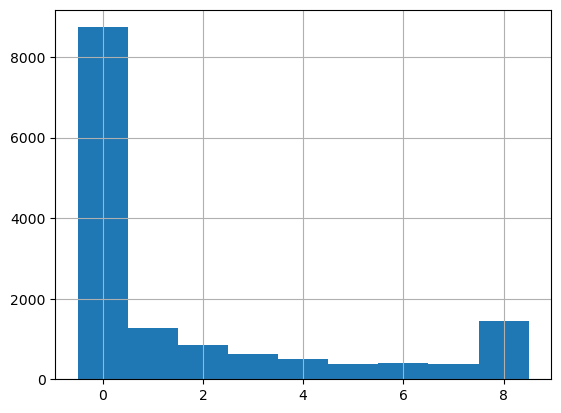

In [94]:
sim_clouds.clouds.hist(bins=np.arange(0, 10)-0.5)

In [95]:
sim_clouds.head()

year  month  sday  eday  clouds
date       quarter                                 
1974-01-01 1        1974      1     1     2       0
           2        1974      1     1     2       0
           3        1974      1     1     2       0
           4        1974      1     1     2       0
1974-01-02 1        1974      1     2     3       0

In [115]:
sim_transitions = pd.DataFrame({'month': sim_clouds.month[:-1].values, 'clouds': sim_clouds.clouds[:-1].values, 'next_clouds': sim_clouds.clouds[1:].values, 'count': 1})
sim_transition_counts = sim_transitions.groupby(['month', 'clouds', 'next_clouds']).count()
sim_transition_matrix = sim_transition_counts.unstack().fillna(0)
sim_transition_matrix.columns = sim_transition_matrix.columns.droplevel(0)

sim_stoch_matrix = counts_to_freq(sim_transition_matrix)
sim_stoch_matrix.loc[1, :]

next_clouds,0,1,2,3,4,5,6,7,8
clouds,,,,,,,,,
0,0.93,0.03,0.01,0.01,0.01,0.00,0.00,0.00,0.01
1,0.38,0.39,0.09,0.04,0.06,0.03,0.00,0.01,0.00
2,0.13,0.27,0.29,0.13,0.11,0.02,0.04,0.00,0.02
3,0.20,0.15,0.17,0.20,0.12,0.15,0.02,0.00,0.00
4,0.09,0.09,0.24,0.24,0.12,0.06,0.06,0.03,0.06
5,0.30,0.00,0.20,0.05,0.20,0.10,0.00,0.15,0.00
6,0.20,0.00,0.20,0.00,0.30,0.30,0.00,0.00,0.00
7,0.22,0.33,0.00,0.00,0.11,0.00,0.22,0.00,0.11
8,0.13,0.07,0.07,0.20,0.00,0.00,0.13,0.13,0.27


In [116]:
stoch_matrix.loc[1, :]

next_clouds,0,1,2,3,4,5,6,7,8
clouds,,,,,,,,,
0,0.94,0.03,0.01,0.01,0.01,0.00,0.00,0.00,0.00
1,0.39,0.39,0.10,0.05,0.04,0.01,0.01,0.00,0.00
2,0.18,0.32,0.28,0.11,0.07,0.01,0.01,0.00,0.01
3,0.18,0.11,0.21,0.27,0.09,0.08,0.04,0.02,0.01
4,0.14,0.06,0.20,0.19,0.23,0.08,0.03,0.04,0.03
5,0.12,0.05,0.12,0.12,0.23,0.24,0.04,0.04,0.03
6,0.04,0.00,0.07,0.07,0.22,0.20,0.18,0.13,0.09
7,0.10,0.13,0.13,0.00,0.19,0.10,0.06,0.13,0.16
8,0.07,0.03,0.06,0.03,0.01,0.03,0.09,0.06,0.61


In [114]:
stoch_matrix - sim_stoch_matrix

next_clouds                     0                    1                    2                    3                    4                    5                    6                    7                    8
month clouds                                                                                                                                                                                             
1     0                      0.01                -0.00                 0.00                -0.00                -0.00                 0.00                 0.00                -0.00                -0.01
      1                      0.02                 0.00                 0.02                 0.00                -0.02                -0.02                 0.01                -0.01                 0.00
      2                      0.06                 0.05                -0.01                -0.02                -0.04                -0.01                -0.02                 0.00                -0.01
      3                     -0.01                -0.03                 0.04                 0.07                -0.04                -0.07                 0.02                 0.02                 0.01
      4                      0.05                -0.04                -0.04                -0.06                 0.11                 0.02                -0.03                 0.01                -0.03
      5                     -0.18                 0.05                -0.08                 0.07                 0.03                 0.14                 0.04                -0.11                 0.03
      6                     -0.16                 0.00                -0.13                 0.07                -0.08                -0.10                 0.18                 0.13                 0.09
      7                     -0.13                -0.20                 0.13                 0.00                 0.08                 0.10                -0.16                 0.13                 0.05
      8                     -0.06                -0.04                -0.01                -0.17                 0.01                 0.03                -0.04                -0.07                 0.35
2     0                      0.00                 0.01                 0.00                 0.00                -0.00                -0.00                -0.00                -0.00                -0.00
      1                      0.01                 0.06                -0.00                -0.05                 0.01                -0.02                -0.02                 0.01                 0.01
      2                     -0.06                 0.03                -0.02                 0.11                -0.08                 0.01                -0.02                 0.01                 0.02
      3                      0.05                -0.14                -0.02                 0.01                 0.02                 0.06                 0.04                -0.03                 0.02
      4                     -0.07                 0.01                 0.12                -0.09                 0.02                -0.06                 0.01                 0.07                 0.00
      5                     -0.20                -0.13                -0.10                 0.04                 0.12                 0.12                 0.13                 0.03                -0.02
      6                     -0.04                -0.02                 0.04                -0.04                 0.12                -0.16                 0.18                -0.10                 0.04
      7                     -0.01                -0.07                -0.02                 0.01                 0.09                 0.06                 0.09                 0.05                -0.19
      8                     -0.03                 0.02                -0.09                 0.06                 0.02                 0.04                -0.09   